# 라리가 2015/16로 다시 만든 VAEP

StatsBomb이 공개한 라리가 2015/16 380경기로 [socceraction](https://github.com/ML-KULeuven/socceraction)의 VAEP 파이프라인을 처음부터 끝까지 돌린 기록이다.
원본 이벤트를 SPADL 행동으로 바꾸고, 행동마다 득점·실점 확률을 예측해, 그 확률 변화로 행동 하나하나에 점수를 매긴다.

맨 위 0번 셀이 데이터 준비부터 학습·평가·그림까지 전부 다시 계산하고, 나머지 셀이 그 결과를 읽어 표와 그림으로 보여준다.
이미 계산된 결과만 보려면 0번 셀의 `RUN_PIPELINE`을 `False`로 바꾼다. 환경과 실행 순서는 `README.md` 참고.

| 절 | 내용 |
|---|---|
| 0 | 결과 만들기 (파이프라인 실행) |
| 1 | 원본 이벤트와 SPADL 행동 — 각각 5행 |
| 2 | VAEP 입력 피처와 라벨 — 각각 5행 |
| 3 | 득점·실점 모델의 평가 결과 |
| 4 | 행동별 공격 가치·수비 가치·VAEP |
| 5 | 선수별 90분당 VAEP 상위 10명 |
| 6 | 한 번의 공격에서 VAEP가 어떻게 변하는가 |

## 0. 결과 만들기

`run_all.py`가 6단계를 순서대로 돌린다: 다운로드 → SPADL 변환 → 피처·라벨 → 모델 학습·평가 → VAEP 계산 → 그림.
처음 돌리면 StatsBomb 원본 1.1GB를 받는다(이미 받았으면 건너뛴다). 학습이 가장 오래 걸린다.

In [1]:
import os, sys, subprocess

RUN_PIPELINE = True     # False로 두면 계산은 건너뛰고 이미 있는 out/ 결과만 읽는다

ROOT = os.path.abspath("")
while not os.path.exists(os.path.join(ROOT, "run_all.py")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)

if RUN_PIPELINE:
    p = subprocess.Popen([sys.executable, "-X", "utf8", "run_all.py", "-q"], cwd=ROOT,
                         stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
                         encoding="utf-8", errors="replace",
                         env={**os.environ, "PYTHONIOENCODING": "utf-8", "PYTHONUNBUFFERED": "1"})
    for line in p.stdout:
        print(line, end="", flush=True)
    if p.wait() != 0:
        raise RuntimeError("파이프라인 실패")
else:
    print("파이프라인 건너뜀 — out/ 에 있는 결과를 읽는다")

[1/6] fetch — StatsBomb 라리가 2015/16 다운로드 (있으면 건너뜀)


   완료: /data/vaep/data/statsbomb (1129 MB)


      0초


[2/6] spadl — 원본 이벤트 -> SPADL 행동 (out/actions.parquet)


   저장: /data/vaep/out/actions.parquet (38 MB)


...

      7초


[6/6] viz — 공격 장면의 VAEP 변화 그림 (figures/sequence.png)


   저장: /data/vaep/figures/sequence.png, /data/vaep/out/sequence.csv


      8초


전체 258초


In [2]:
import json, gzip
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.join(ROOT, "src"))
import style, viz                                   # 그림 스타일과 경기장 그리기
from config import MIN_MINUTES, SB_DIR, OUT, FIG, NB_PREV_ACTIONS, XGB_PARAMS, N_FOLDS, SEED
import socceraction.spadl as spadl
style.use()
pd.set_option("display.max_columns", 60, "display.width", 220)

games   = pd.read_parquet(f"{OUT}/games.parquet")
teams   = pd.read_parquet(f"{OUT}/teams.parquet")
players = pd.read_parquet(f"{OUT}/players.parquet")
actions = pd.read_parquet(f"{OUT}/actions.parquet")
X       = pd.read_parquet(f"{OUT}/features.parquet")
Y       = pd.read_parquet(f"{OUT}/labels.parquet")
preds   = pd.read_parquet(f"{OUT}/predictions.parquet")
values  = pd.read_parquet(f"{OUT}/action_values.parquet")
metrics = pd.read_csv(f"{OUT}/metrics.csv")
ratings = pd.read_csv(f"{OUT}/player_ratings.csv")

team_name = teams.set_index("team_id").team_name
print(f"경기 {len(games)}개 · 행동 {len(actions):,}개 · 피처 {X.shape[1] - 2}개 · 선수 {len(players)}명")
print(f"기간 {games.game_date.min():%Y-%m-%d} ~ {games.game_date.max():%Y-%m-%d}")

경기 380개 · 행동 757,309개 · 피처 145개 · 선수 539명
기간 2015-08-21 ~ 2016-05-15


## 1. 원본 이벤트와 SPADL 행동

StatsBomb 원본은 한 경기가 3,000개 넘는 이벤트로 되어 있고, 공급자마다 표기가 다르다.
SPADL은 이 중 '선수가 공에 한 행동'만 남겨 **누가 · 언제 · 어디서 어디로 · 무엇을 · 성공했는가**라는 같은 형식으로 통일한다.
공급자가 달라도 같은 코드로 다룰 수 있게 하는 게 목적이다.

아래는 같은 경기(2015-11-21 엘 클라시코)를 두 형식으로 본 것이다.

In [3]:
# 엘 클라시코 한 경기를 골라 원본과 SPADL을 나란히 본다
g = games.merge(teams.add_prefix("home_"), on="home_team_id").merge(teams.add_prefix("away_"), on="away_team_id")
demo = g[(g.home_team_name == "Real Madrid") & (g.away_team_name == "Barcelona")]
demo = (demo if len(demo) else g.sort_values("game_date")).iloc[0]
GAME_ID = int(demo.game_id)
print(f"{demo.home_team_name} {demo.home_score}-{demo.away_score} {demo.away_team_name}"
      f"  ({demo.game_date:%Y-%m-%d}, game_id={GAME_ID})")

Real Madrid 0-4 Barcelona  (2015-11-21, game_id=266424)


In [4]:
# (1) StatsBomb 원본 이벤트 5행 — 받은 JSON 그대로
with open(f"{SB_DIR}/events/{GAME_ID}.json", encoding="utf-8") as f:
    raw = pd.json_normalize(json.load(f))
print(f"원본 이벤트 {len(raw):,}개 · 컬럼 {raw.shape[1]}개")
display(raw.head(5)[["id", "index", "period", "timestamp", "type.name", "team.name",
                     "player.name", "position.name", "location", "pass.end_location",
                     "pass.recipient.name", "pass.height.name", "play_pattern.name"]])

원본 이벤트 3,860개 · 컬럼 117개


,id,index,period,timestamp,type.name,team.name,player.name,position.name,location,pass.end_location,pass.recipient.name,pass.height.name,play_pattern.name
0,5affd831-590f-4e98-a908-d08bd4e5b869,1,1,00:00:00.000,Starting XI,Real Madrid,NaN,NaN,NaN,NaN,NaN,NaN,Regular Play
1,ec49ca6b-4eb5-4d10-8e2c-981a33b5e970,2,1,00:00:00.000,Starting XI,Barcelona,NaN,NaN,NaN,NaN,NaN,NaN,Regular Play
2,6d900b31-be0e-4a53-b058-38c98d4dc9da,3,1,00:00:00.000,Half Start,Real Madrid,NaN,NaN,NaN,NaN,NaN,NaN,Regular Play
3,2d93744e-e07b-4d65-8353-a7321e2124bb,4,1,00:00:00.000,Half Start,Barcelona,NaN,NaN,NaN,NaN,NaN,NaN,Regular Play
4,81777385-a4cd-47df-ac69-950ea2965b74,5,1,00:00:00.602,Pass,Barcelona,Neymar da Silva Santos Junior,Left Wing,"[61.0, 40.1]","[60.3, 43.8]",Luis Alberto Suárez Díaz,Ground Pass,From Kick Off


In [5]:
# (2) 같은 경기의 SPADL 행동 5행 — 한 경기가 이벤트 3천여 개에서 행동 2천여 개로 줄어든다
demo_actions = (spadl.add_names(actions[actions.game_id == GAME_ID])
                .merge(players, on="player_id", how="left")
                .merge(teams, on="team_id", how="left"))
print(f"SPADL 행동 {len(demo_actions):,}개 · 컬럼 {actions.shape[1]}개")
display(demo_actions.head(5)[["game_id", "action_id", "period_id", "time_seconds", "team_name",
                              "player_name", "start_x", "start_y", "end_x", "end_y",
                              "type_name", "result_name", "bodypart_name"]])

SPADL 행동 2,297개 · 컬럼 14개


,game_id,action_id,period_id,time_seconds,team_name,player_name,start_x,start_y,end_x,end_y,type_name,result_name,bodypart_name
0,266424,0,1,0.602,Barcelona,Neymar da Silva Santos Junior,51.66875,34.0425,52.28125,37.1875,pass,success,foot_left
1,266424,1,1,0.810,Barcelona,Luis Alberto Suárez Díaz,52.28125,37.1875,51.93125,37.0175,dribble,success,foot
2,266424,2,1,1.003,Barcelona,Luis Alberto Suárez Díaz,51.93125,37.0175,63.83125,32.5125,pass,success,foot_right
3,266424,3,1,2.638,Barcelona,Sergio Busquets i Burgos,63.83125,32.5125,64.44375,33.1075,dribble,success,foot
4,266424,4,1,3.598,Barcelona,Sergio Busquets i Burgos,64.44375,33.1075,64.44375,33.1075,take_on,success,foot


In [6]:
# SPADL이 쓰는 행동 유형 23가지와 이 시즌의 사용 빈도
cnt = spadl.add_names(actions).type_name.value_counts()
display(cnt.rename("행동 수").to_frame().T)

type_name,pass,dribble,interception,throw_in,clearance,tackle,take_on,foul,bad_touch,cross,shot,goalkick,freekick_short,freekick_crossed,corner_crossed,keeper_save,keeper_claim,corner_short,keeper_punch,shot_freekick,shot_penalty
행동 수,314978,295075,17899,17389,16217,15052,14550,12136,10451,8677,8662,5974,5790,5698,2897,2195,1741,872,550,409,97


## 2. VAEP 입력 피처와 라벨

**피처.** VAEP는 행동 하나만 보지 않고 **게임 상태**(지금 행동 + 직전 2개 행동)를 본다.
같은 위치의 패스라도 직전에 무슨 일이 있었는지에 따라 가치가 다르기 때문이다.
행동 하나마다 `a0`(지금), `a1`(하나 전), `a2`(둘 전)의 위치·유형·결과·시간 간격 등을 뽑아 145개 열이 된다.
공격 방향은 모두 왼쪽 → 오른쪽으로 뒤집어 맞춘다.

**라벨.** 각 행동 시점에서 앞으로 **10개 행동 안에** 공을 가진 팀이 골을 넣으면 `scores=1`, 먹으면 `concedes=1`이다.

In [7]:
feat_cols = [c for c in X.columns if c not in ("game_id", "action_id")]
show = ["actiontype_pass_a0", "actiontype_shot_a0", "start_x_a0", "start_y_a0", "end_x_a0",
        "end_y_a0", "dx_a0", "dy_a0", "movement_a0", "start_dist_to_goal_a0",
        "start_angle_to_goal_a0", "end_dist_to_goal_a0", "team_1", "time_delta_1",
        "goalscore_team", "goalscore_diff"]
show = [c for c in show if c in feat_cols]
print(f"피처 {len(feat_cols)}개 중 일부 (전체 목록은 아래 셀)")
display(X.head(5)[["game_id", "action_id"] + show])

피처 145개 중 일부 (전체 목록은 아래 셀)


,game_id,action_id,actiontype_pass_a0,actiontype_shot_a0,start_x_a0,start_y_a0,end_x_a0,end_y_a0,dx_a0,dy_a0,movement_a0,start_dist_to_goal_a0,start_angle_to_goal_a0,end_dist_to_goal_a0,team_1,time_delta_1,goalscore_team,goalscore_diff
0,3825562,0,True,False,52.45625,34.0425,51.93125,32.1725,-0.5250,-1.870,1.942299,52.543767,0.000809,53.100207,True,0.000,0,0
1,3825562,1,True,False,51.93125,34.5525,36.53125,37.3575,-15.4000,2.805,15.653371,53.071626,0.010411,68.551021,True,0.758,0,0
2,3825562,2,False,False,36.53125,37.3575,37.05625,40.6725,0.5250,3.315,3.356315,68.551021,0.048998,68.270604,True,1.460,0,0
3,3825562,3,True,False,37.05625,40.6725,35.65625,62.4325,-1.4000,21.760,21.804990,68.270604,0.097892,74.946399,True,1.460,0,0
4,3825562,4,False,False,35.65625,62.4325,33.29375,58.6925,-2.3625,-3.740,4.423687,74.946399,0.389117,75.838683,True,1.702,0,0


In [8]:
# 피처 145개가 무엇을 보는지 — socceraction의 변환 함수 단위로 묶어서
import socceraction.vaep.features as fs
from build_features import XFN_NAMES

DESC = {
    "actiontype_onehot": "행동 유형 23가지 (패스, 드리블, 슛, 태클, ...)",
    "bodypart_onehot": "발 / 머리 / 그 외",
    "result_onehot": "성공 / 실패 / 오프사이드 / 자책골 / 퇴장 유발",
    "goalscore": "현재 스코어와 골 차",
    "startlocation": "행동 시작 좌표",
    "endlocation": "행동 끝 좌표",
    "movement": "이동한 거리 (dx, dy, 직선거리)",
    "space_delta": "직전 행동과 벌어진 거리",
    "startpolar": "시작점에서 상대 골대까지 거리·각도",
    "endpolar": "끝점에서 상대 골대까지 거리·각도",
    "team": "직전 행동이 같은 팀 것인가",
    "time_delta": "직전 행동과의 시간 차이(초)",
}
rows = []
for n in XFN_NAMES:
    cs = fs.feature_column_names([getattr(fs, n)], NB_PREV_ACTIONS)
    rows.append({"피처 묶음": n, "설명": DESC[n], "열": len(cs), "예": ", ".join(cs[:3])})
print(f"게임 상태 = 지금 행동(a0) + 직전 {NB_PREV_ACTIONS - 1}개(a1, a2), 총 {len(feat_cols)}개 열")
display(pd.DataFrame(rows).style.hide(axis="index"))

게임 상태 = 지금 행동(a0) + 직전 2개(a1, a2), 총 145개 열


피처 묶음,설명,열,예
actiontype_onehot,"행동 유형 23가지 (패스, 드리블, 슛, 태클, ...)",69,"actiontype_pass_a0, actiontype_cross_a0, actiontype_throw_in_a0"
bodypart_onehot,발 / 머리 / 그 외,12,"bodypart_foot_a0, bodypart_head_a0, bodypart_other_a0"
result_onehot,성공 / 실패 / 오프사이드 / 자책골 / 퇴장 유발,18,"result_fail_a0, result_success_a0, result_offside_a0"
goalscore,현재 스코어와 골 차,3,"goalscore_team, goalscore_opponent, goalscore_diff"
startlocation,행동 시작 좌표,6,"start_x_a0, start_y_a0, start_x_a1"
endlocation,행동 끝 좌표,6,"end_x_a0, end_y_a0, end_x_a1"
movement,"이동한 거리 (dx, dy, 직선거리)",9,"dx_a0, dy_a0, movement_a0"
space_delta,직전 행동과 벌어진 거리,6,"dx_a01, dy_a01, mov_a01"
startpolar,시작점에서 상대 골대까지 거리·각도,6,"start_dist_to_goal_a0, start_angle_to_goal_a0, start_dist_to_goal_a1"
endpolar,끝점에서 상대 골대까지 거리·각도,6,"end_dist_to_goal_a0, end_angle_to_goal_a0, end_dist_to_goal_a1"


In [9]:
# 라벨 5행 — 같은 행 순서로 붙어 있다
display(Y.head(5))
print(f"scores   = 1 인 행동: {Y.scores.mean() * 100:.2f}%  ({int(Y.scores.sum()):,}개)")
print(f"concedes = 1 인 행동: {Y.concedes.mean() * 100:.2f}%  ({int(Y.concedes.sum()):,}개)")

,game_id,action_id,scores,concedes
0,3825562,0,False,False
1,3825562,1,False,False
2,3825562,2,False,False
3,3825562,3,False,False
4,3825562,4,False,False


scores   = 1 인 행동: 1.10%  (8,354개)
concedes = 1 인 행동: 0.24%  (1,782개)


In [10]:
# 라벨이 실제로 골 근처에서 켜지는지 눈으로 확인 — 골로 끝난 공격의 마지막 12개 행동
named = spadl.add_names(actions)
goal_idx = named[(named.type_name == "shot") & (named.result_name == "success")].index[3]
win = named.loc[goal_idx - 11:goal_idx].join(Y[["scores", "concedes"]]).merge(
    players, on="player_id", how="left")
display(win[["time_seconds", "player_name", "type_name", "result_name", "scores", "concedes"]]
        .tail(12).reset_index(drop=True))

,time_seconds,player_name,type_name,result_name,scores,concedes
0,1807.628,Samuel Castillejo Azuaga,pass,fail,False,False
1,1808.362,Germán Alejandro Pezzella,clearance,success,False,False
2,1828.729,Samuel Castillejo Azuaga,corner_crossed,fail,True,False
3,1830.261,Germán Alejandro Pezzella,clearance,success,False,True
4,1849.442,Samuel Castillejo Azuaga,corner_crossed,success,True,False
5,1850.570,Eric Bertrand Bailly,dribble,success,True,False
6,1851.698,Eric Bertrand Bailly,pass,fail,True,False
7,1852.417,Álvaro Cejudo Carmona,clearance,success,False,True
8,1855.461,Jaume Vicent Costa Jordá,dribble,success,True,False
9,1856.325,Jaume Vicent Costa Jordá,pass,success,True,False


## 3. 득점·실점 모델의 평가 결과

XGBoost 분류기 두 개를 학습한다. 하나는 `scores`(앞으로 10행동 안에 득점), 다른 하나는 `concedes`(실점)를 맞힌다.
평가는 두 가지로 한다.

- **OOF**: 380경기를 경기 단위 5겹으로 나눠, 각 경기를 그 경기가 학습에 들어가지 않은 모델로 예측한다. 4·5·6절의 VAEP 값은 모두 이 예측을 쓴다.
- **홀드아웃**: 날짜순 앞 80%(304경기)로 학습해 마지막 76경기를 한 번만 예측한다. 시즌 앞부분만 보고 뒷부분을 맞힐 수 있는지 확인하는 최종 점검이다.

`scores`는 100번에 1번, `concedes`는 400번에 1번 일어나는 드문 사건이라 정확도는 의미가 없다.
확률을 얼마나 잘 맞혔는지(Brier, log loss)와 순서를 얼마나 잘 매겼는지(ROC AUC)로 본다.
**Brier skill**은 '항상 평균값만 찍는 모델' 대비 개선율로, 0이면 그 모델과 같고 1이면 완벽하다.

In [11]:
t = metrics.copy()
t["split"] = t.split.map({"oof": "OOF (5겹)", "holdout": "홀드아웃 (마지막 76경기)"})
t["label"] = t.label.map({"scores": "득점 확률", "concedes": "실점 확률"})
t["AUC 95% 구간"] = t.apply(lambda r: f"{r.auc_lo:.3f} ~ {r.auc_hi:.3f}", axis=1)
display(t[["split", "label", "n", "base_rate", "brier", "brier_base", "brier_skill",
           "log_loss", "roc_auc", "AUC 95% 구간"]]
        .rename(columns={"split": "평가 방식", "label": "대상", "n": "행동 수",
                         "base_rate": "기저율", "brier": "Brier", "brier_base": "Brier(기저)",
                         "brier_skill": "Brier skill", "log_loss": "log loss", "roc_auc": "ROC AUC"})
        .style.format({"행동 수": "{:,}", "기저율": "{:.4f}", "Brier": "{:.5f}",
                       "Brier(기저)": "{:.5f}", "Brier skill": "{:.3f}",
                       "log loss": "{:.4f}", "ROC AUC": "{:.3f}"}).hide(axis="index"))

평가 방식,대상,행동 수,기저율,Brier,Brier(기저),Brier skill,log loss,ROC AUC,AUC 95% 구간
OOF (5겹),득점 확률,"757,309",0.0110,0.00927,0.01091,0.150,0.0476,0.819,0.812 ~ 0.827
OOF (5겹),실점 확률,"757,309",0.0024,0.00226,0.00235,0.036,0.0146,0.767,0.747 ~ 0.785
홀드아웃 (마지막 76경기),득점 확률,"153,438",0.0111,0.00932,0.01096,0.149,0.0481,0.813,0.791 ~ 0.834
홀드아웃 (마지막 76경기),실점 확률,"153,438",0.0022,0.00211,0.00221,0.043,0.0135,0.782,0.737 ~ 0.831


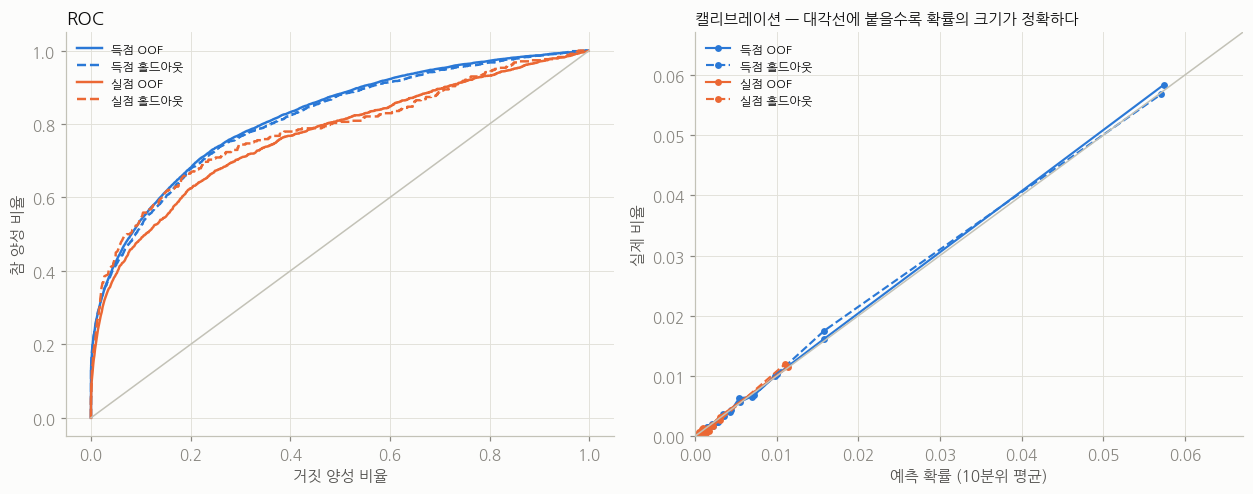

In [12]:
# ROC와 캘리브레이션 — 순서를 잘 매기는가, 확률의 크기가 맞는가
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

hold = pd.read_parquet(f"{OUT}/predictions_holdout.parquet")
Yh = Y.set_index(["game_id", "action_id"]).loc[
    pd.MultiIndex.from_frame(hold[["game_id", "action_id"]])].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
cal = []
for label, color in [("scores", style.BLUE), ("concedes", style.ORANGE)]:
    for (yy, pp, ls, tag) in [(Y[label], preds[label], "-", "OOF"),
                              (Yh[label], hold[label], "--", "홀드아웃")]:
        fpr, tpr, _ = roc_curve(yy, pp)
        step = max(1, len(fpr) // 2000)      # 곡선의 점이 수십만 개라 솎아 그린다 (모양은 같다)
        axes[0].plot(fpr[::step], tpr[::step], ls, color=color, lw=1.6,
                     label=f"{'득점' if label == 'scores' else '실점'} {tag}")
        frac, mean = calibration_curve(yy, pp, n_bins=10, strategy="quantile")
        axes[1].plot(mean, frac, ls, marker="o", ms=3.5, color=color, lw=1.4,
                     label=f"{'득점' if label == 'scores' else '실점'} {tag}")
        cal += [mean.max(), frac.max()]
axes[0].plot([0, 1], [0, 1], color=style.BASE, lw=1)
axes[0].set_xlabel("거짓 양성 비율"); axes[0].set_ylabel("참 양성 비율"); axes[0].set_title("ROC", loc="left")
axes[0].legend(fontsize=8)
lim = max(cal) * 1.15
axes[1].plot([0, lim], [0, lim], color=style.BASE, lw=1)
axes[1].set_xlim(0, lim); axes[1].set_ylim(0, lim)
axes[1].set_xlabel("예측 확률 (10분위 평균)"); axes[1].set_ylabel("실제 비율")
axes[1].set_title("캘리브레이션 — 대각선에 붙을수록 확률의 크기가 정확하다", loc="left", fontsize=10)
axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(f"{FIG}/model_eval.png", dpi=150, bbox_inches="tight")
plt.show()

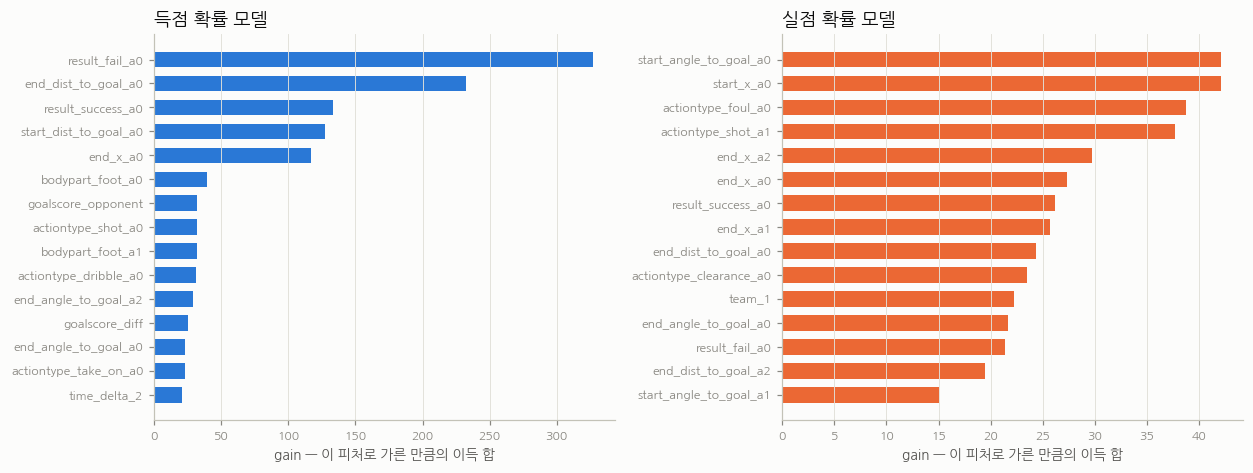

In [13]:
# 모델이 무엇을 보고 판단하는가 (홀드아웃 학습 모델의 gain 기준 상위 15개)
imp = pd.read_csv(f"{OUT}/feature_importance.csv", index_col="feature")
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharex=False)
for ax, (col, title, color) in zip(axes, [("scores", "득점 확률 모델", style.BLUE),
                                          ("concedes", "실점 확률 모델", style.ORANGE)]):
    top = imp[col].sort_values(ascending=False).head(15)[::-1]
    ax.barh(top.index, top.values, color=color, height=0.65)
    ax.set_title(title, loc="left"); ax.tick_params(labelsize=8); ax.grid(axis="y", alpha=0)
    ax.set_xlabel("gain — 이 피처로 가른 만큼의 이득 합", fontsize=9)
fig.tight_layout(); fig.savefig(f"{FIG}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 행동별 공격 가치, 수비 가치, VAEP

확률이 준비되면 값은 뺄셈이다.

- **공격 가치** = 이 행동 뒤의 득점 확률 − 행동 직전의 득점 확률
- **수비 가치** = −(이 행동 뒤의 실점 확률 − 행동 직전의 실점 확률)
- **VAEP** = 공격 가치 + 수비 가치

즉 '이 행동이 우리 팀이 골을 넣을 가능성을 얼마나 올리고, 먹을 가능성을 얼마나 줄였나'다.
직전 행동이 상대 팀 것이면 상대의 득점 확률을 우리 실점 확률로 뒤집어 비교하고,
직전 행동이 10초보다 오래 전이면 새 국면으로 보고 0에서 시작한다.

In [14]:
av = spadl.add_names(actions).merge(values, on=["game_id", "action_id"])
av = av.merge(preds.rename(columns={"scores": "p_scores", "concedes": "p_concedes"}),
              on=["game_id", "action_id"]).merge(players, on="player_id", how="left")
av["name"] = av.nickname.fillna(av.player_name)

# 값이 큰 행동 5개와 작은 행동 5개
cols = ["name", "type_name", "result_name", "start_x", "start_y", "end_x", "end_y",
        "p_scores", "p_concedes", "offensive_value", "defensive_value", "vaep_value"]
print("VAEP가 가장 높은 행동 5개")
display(av.nlargest(5, "vaep_value")[cols].style.format(precision=4).hide(axis="index"))
print("VAEP가 가장 낮은 행동 5개")
display(av.nsmallest(5, "vaep_value")[cols].style.format(precision=4).hide(axis="index"))

VAEP가 가장 높은 행동 5개


name,type_name,result_name,start_x,start_y,end_x,end_y,p_scores,p_concedes,offensive_value,defensive_value,vaep_value
Rafinha,shot,success,97.7812,30.0475,104.9563,32.2575,0.9900,0.0011,0.9835,0.0004,0.9839
Fran Rico,shot,success,91.8313,32.7675,104.9563,36.3375,0.9838,0.0019,0.9768,0.0034,0.9803
Karim Benzema,shot,success,98.9187,34.2975,104.9563,34.2975,0.9750,0.0015,0.9694,0.0004,0.9698
Lucas Pérez,shot,success,101.6313,36.4225,104.9563,35.6575,0.9734,0.0009,0.9668,0.0015,0.9683
Ivan Rakitić,shot,success,11.0687,28.9425,0.0437,31.7475,0.9784,0.0011,0.9669,0.0007,0.9676


VAEP가 가장 낮은 행동 5개


name,type_name,result_name,start_x,start_y,end_x,end_y,p_scores,p_concedes,offensive_value,defensive_value,vaep_value
Rubén Castro,shot_penalty,fail,10.3688,33.9575,1.5312,35.9975,0.0143,0.0042,-0.7782,-0.0042,-0.7824
Isco,shot,fail,7.3063,31.9175,0.8312,33.8725,0.0280,0.0059,-0.7760,-0.0047,-0.7808
Jony,shot_penalty,fail,94.6312,33.9575,104.0813,36.0825,0.0196,0.0025,-0.7728,-0.0025,-0.7753
Aritz Aduriz,shot_penalty,fail,94.4563,34.0425,104.9563,37.4425,0.0213,0.0023,-0.7712,-0.0023,-0.7735
Cristiano Ronaldo,shot_penalty,fail,94.6312,33.9575,104.9563,33.6175,0.0218,0.0024,-0.7707,-0.0024,-0.7731


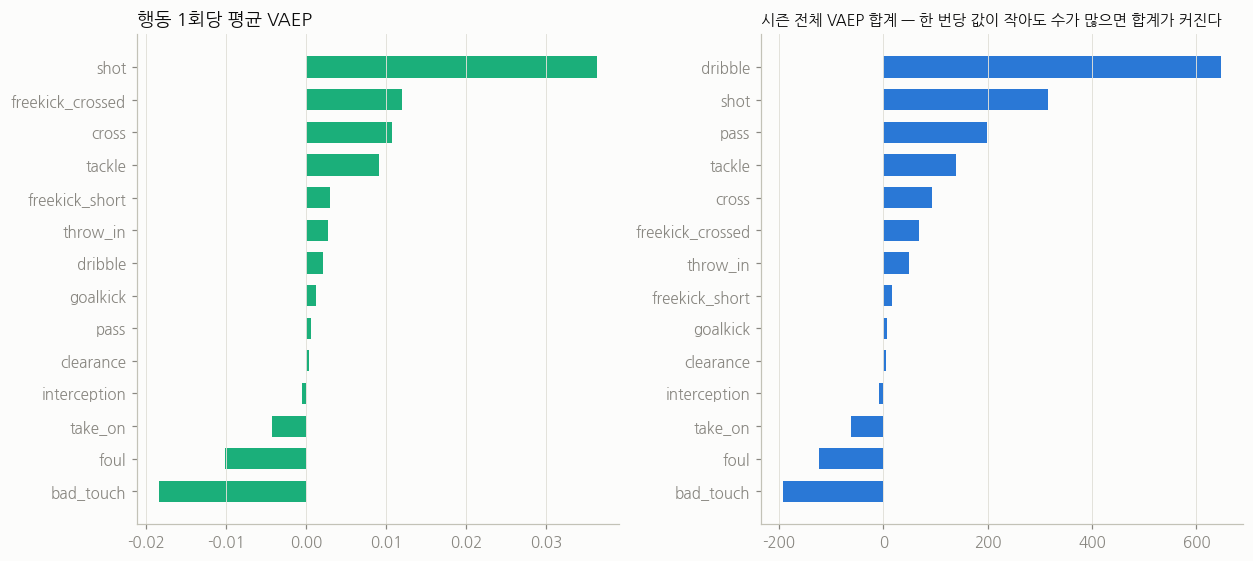

type_name,n,offensive_mean,defensive_mean,vaep_mean,vaep_sum
dribble,"295,075",0.00180,0.00039,0.00219,647.4
shot,"8,662",0.03763,-0.00126,0.03637,315.1
pass,"314,978",0.00069,-0.00006,0.00063,198.5
tackle,"15,052",0.00248,0.00672,0.00919,138.4
cross,"8,677",0.01179,-0.00099,0.01080,93.7
freekick_crossed,"5,698",0.01370,-0.00164,0.01206,68.7
throw_in,"17,389",0.00346,-0.00067,0.00278,48.4
shot_freekick,409,0.07466,-0.00245,0.07221,29.5
freekick_short,"5,790",0.00382,-0.00084,0.00298,17.2
keeper_claim,"1,741",0.00017,0.00714,0.00731,12.7


In [15]:
# 행동 유형별 — 어떤 행동이 얼마나 자주 나오고 평균 몇 점짜리인가
by_type = pd.read_csv(f"{OUT}/value_by_actiontype.csv")
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
top = by_type.nlargest(14, "n").sort_values("vaep_mean")
axes[0].barh(top.type_name, top.vaep_mean, color=style.AQUA, height=0.65)
axes[0].set_title("행동 1회당 평균 VAEP", loc="left"); axes[0].grid(axis="y", alpha=0)
tot = by_type.nlargest(14, "n").sort_values("vaep_sum")
axes[1].barh(tot.type_name, tot.vaep_sum, color=style.BLUE, height=0.65)
axes[1].set_title("시즌 전체 VAEP 합계 — 한 번당 값이 작아도 수가 많으면 합계가 커진다", loc="left", fontsize=10)
axes[1].grid(axis="y", alpha=0)
fig.tight_layout(); fig.savefig(f"{FIG}/value_by_actiontype.png", dpi=150, bbox_inches="tight")
plt.show()
display(by_type.head(12).style.format({"n": "{:,}", "offensive_mean": "{:.5f}",
        "defensive_mean": "{:.5f}", "vaep_mean": "{:.5f}", "vaep_sum": "{:.1f}"}).hide(axis="index"))

## 5. 선수별 90분당 VAEP 상위 10명

선수가 한 모든 행동의 VAEP를 더하고 출전 시간으로 나눈다.
표본이 적은 선수가 올라오는 것을 막기 위해 시즌 **900분(10경기)** 이상 뛴 선수만 본다.

In [16]:
elig = ratings[ratings.minutes >= MIN_MINUTES].copy()
top10 = elig.nlargest(10, "vaep_p90")
print(f"{MIN_MINUTES}분 이상 뛴 선수 {len(elig)}명 중 상위 10명")
display(top10[["name", "team_name", "games", "minutes", "actions",
               "offensive_p90", "defensive_p90", "vaep_p90", "vaep"]]
        .rename(columns={"name": "선수", "team_name": "팀", "games": "경기", "minutes": "출전(분)",
                         "actions": "행동 수", "offensive_p90": "공격/90", "defensive_p90": "수비/90",
                         "vaep_p90": "VAEP/90", "vaep": "VAEP 합계"})
        .style.format({"출전(분)": "{:,.0f}", "행동 수": "{:,}", "공격/90": "{:.3f}",
                       "수비/90": "{:.3f}", "VAEP/90": "{:.3f}", "VAEP 합계": "{:.1f}"})
        .hide(axis="index"))

900분 이상 뛴 선수 343명 중 상위 10명


선수,팀,경기,출전(분),행동 수,공격/90,수비/90,VAEP/90,VAEP 합계
Gareth Bale,Real Madrid,23,"1,784","1,820",0.866,-0.022,0.845,16.7
Lionel Messi,Barcelona,33,"2,818","4,520",0.833,-0.026,0.807,25.3
James Rodríguez,Real Madrid,26,"1,568","2,562",0.623,-0.010,0.613,10.7
Karim Benzema,Real Madrid,27,"2,023","1,597",0.589,-0.018,0.571,12.8
Luis Suárez,Barcelona,35,"3,257","2,493",0.549,-0.025,0.524,19.0
Imanol Agirretxe,Real Sociedad,16,"1,207",728,0.544,-0.032,0.512,6.9
Antoine Griezmann,Atlético Madrid,38,"3,134","3,099",0.456,-0.006,0.450,15.7
Neymar,Barcelona,34,"3,148","4,797",0.478,-0.035,0.443,15.5
Nolito,Celta Vigo,29,"2,575","2,983",0.439,-0.031,0.408,11.7
Éver Banega,Sevilla,25,"1,776","2,717",0.387,-0.004,0.383,7.6


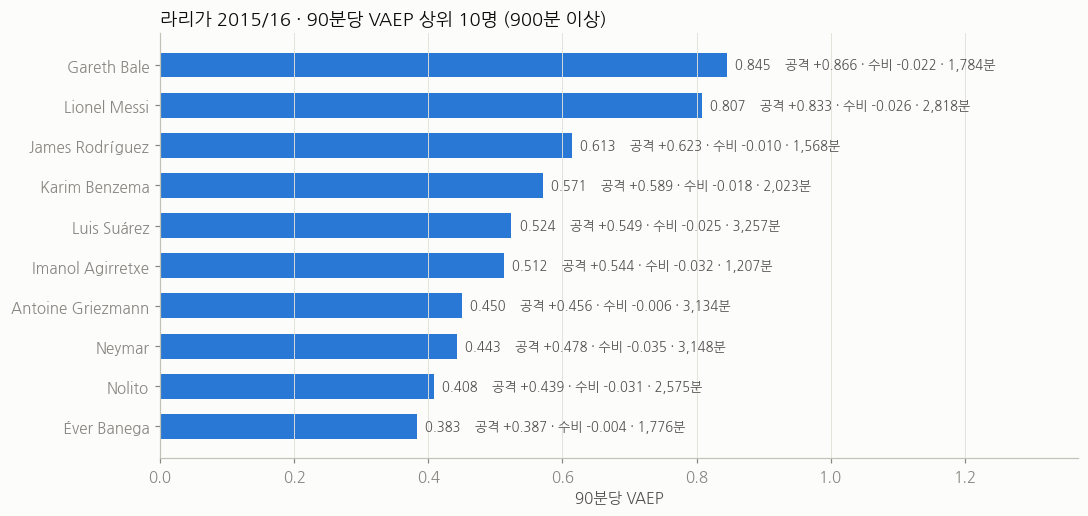

In [17]:
# 수비 가치는 대부분 음수라 누적 막대로 그리면 오해를 부른다. 막대는 합계, 분해는 글자로 적는다.
fig, ax = plt.subplots(figsize=(10, 4.8))
t = top10.sort_values("vaep_p90")
ax.barh(t.name, t.vaep_p90, color=style.BLUE, height=0.62)
for y, r in enumerate(t.itertuples()):
    ax.text(r.vaep_p90 + 0.012, y,
            f"{r.vaep_p90:.3f}    공격 {r.offensive_p90:+.3f} · 수비 {r.defensive_p90:+.3f} · {r.minutes:,.0f}분",
            va="center", fontsize=8.5, color=style.INK2)
ax.set_xlabel("90분당 VAEP"); ax.grid(axis="y", alpha=0)
ax.set_title("라리가 2015/16 · 90분당 VAEP 상위 10명 (900분 이상)", loc="left")
ax.set_xlim(0, t.vaep_p90.max() * 1.62)
fig.tight_layout(); fig.savefig(f"{FIG}/top_players.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 한 번의 공격에서 VAEP가 어떻게 변하는가

지금까지는 합계였다. VAEP의 원래 쓸모는 **한 장면 안에서 누가 무엇을 해서 확률이 움직였는지**를 쪼개 보는 것이다.
골로 끝난 공격 중 같은 팀의 연속 행동이 길고 VAEP 합이 큰 장면을 하나 골랐다.

아래 그림에서 위는 경기장 위의 행동 흐름(화살표 색이 진할수록 VAEP가 크다), 아래는 행동별 VAEP 막대와
파란 선(그 행동 직후 10행동 안에 득점할 확률)이다. 확률이 계단처럼 올라가고, 그 계단 하나하나가 그 행동을 한 선수의 몫이 된다.

In [18]:
seq = pd.read_csv(f"{OUT}/sequence.csv")
sg = games[games.game_id == seq.game_id.iloc[0]].iloc[0]
minute = int(seq.time_seconds.iloc[-1] // 60) + (45 if seq.period_id.iloc[-1] == 2 else 0)
title = (f"{team_name[sg.home_team_id]} {sg.home_score}-{sg.away_score} {team_name[sg.away_team_id]}"
         f"  ({sg.game_date:%Y-%m-%d})  ·  {seq.team_name.iloc[0]}의 {minute}분 득점 장면"
         f"  ·  VAEP 합계 {seq.vaep_value.sum():+.3f}")
display(seq[["name", "type_name", "result_name", "p_scores", "p_concedes",
             "offensive_value", "defensive_value", "vaep_value"]]
        .rename(columns={"name": "선수", "type_name": "행동", "result_name": "결과",
                         "p_scores": "득점 확률", "p_concedes": "실점 확률",
                         "offensive_value": "공격 가치", "defensive_value": "수비 가치",
                         "vaep_value": "VAEP"})
        .style.format(precision=4).hide(axis="index"))
print(title)

선수,행동,결과,득점 확률,실점 확률,공격 가치,수비 가치,VAEP
Denis Suárez,clearance,success,0.0054,0.0152,0.0011,0.0116,0.0127
Jaume Costa,pass,success,0.0079,0.0018,0.0026,0.0134,0.0160
Denis Suárez,dribble,success,0.0065,0.0018,-0.0014,0.0000,-0.0014
Denis Suárez,pass,success,0.0135,0.0010,0.0070,0.0008,0.0078
Adrián López,dribble,success,0.0392,0.0007,0.0257,0.0004,0.0260
Adrián López,take_on,success,0.0462,0.0009,0.0070,-0.0002,0.0068
Adrián López,dribble,success,0.0329,0.0013,-0.0133,-0.0004,-0.0137
Adrián López,pass,success,0.0728,0.0011,0.0399,0.0002,0.0401
Léo Baptistão,dribble,success,0.1051,0.0011,0.0323,-0.0000,0.0323
Léo Baptistão,shot,success,0.9783,0.0010,0.8732,0.0001,0.8733


Villarreal 3-1 Athletic Club  (2015-09-20)  ·  Villarreal의 79분 득점 장면  ·  VAEP 합계 +1.000


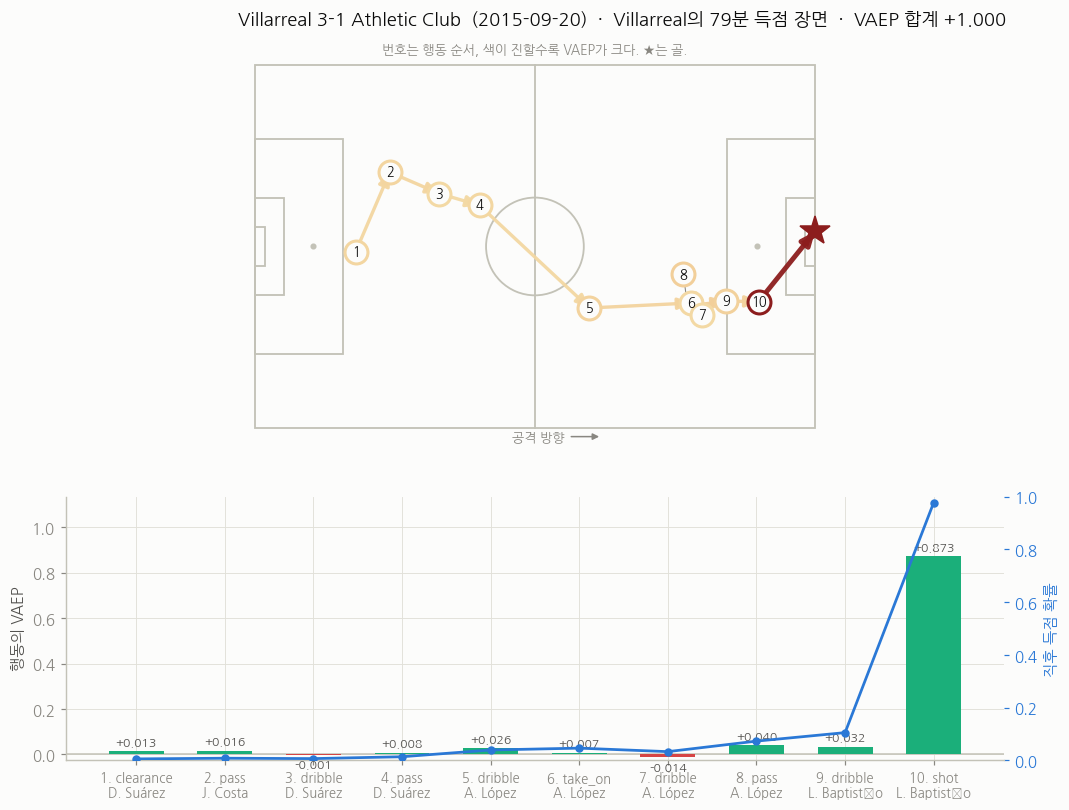

In [19]:
fig = viz.plot_sequence(seq, title, pscore=seq.p_scores.values)
fig.savefig(f"{FIG}/sequence.png", dpi=150, bbox_inches="tight")
plt.show()

---

### 정리

- 380경기 · 757,309개 행동을 SPADL로 통일하고, 게임 상태 145개 피처로 득점·실점 확률을 예측한 뒤, 그 확률 변화를 행동마다 나눠 가졌다.
- 값은 모두 **그 경기를 학습에 쓰지 않은 모델**의 예측에서 나온 것이라, 선수 랭킹이 자기 경기를 외운 결과가 아니다.
- 한계: 공을 가진 행동만 값을 받는다. 공간을 만드는 움직임, 수비 위치잡기, 골키퍼의 선방 대부분은 이벤트 데이터에 없어 0점이다.
  10행동/10초라는 구간 설정과 페널티·코너의 고정 확률도 VAEP 논문의 값을 그대로 쓴 것이다.